BANK CUSTOMER CHURN PREDICITION
The purpose of this project is to analyze customer profiles and identify the factors that influence customer churn, with the goal of estimating the likelihood that a customer will leave the bank.
By identifying high-risk customers at an early stage, the bank can take targeted retention measures to improve customer retention, reduce recurring revenue losses, and minimize customer acquisition costs.

In [ ]:
# Import libraries
import kagglehub
import os
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

DATASET
The dataset used in this project was sourced from Kaggle. It contains 64.374 customer records across 12 columns, including attributes such as customer age, gender, tenure, payment delays, and other customer-related characteristics.
It provides the foundation for exploring patterns in customer behavior and determining which factors are most strongly associated with churn.

In [41]:
# Load dataset
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")
file = os.path.join(path, 'Bank Customer Churn Prediction.csv')

# Create dataframe
df = pd.read_csv(file)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [42]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Check for duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)  

# Compute dummy variables for categorical features
df = pd.get_dummies(df, columns=['country', 'gender'], dtype=int)


Missing values in each column:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
Number of duplicate rows: 0


In [31]:
# Statistical summary of the dataset
df.drop(columns=['customer_id'], inplace=True)
df.describe()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.501400,0.250900,0.247700,0.454300,0.545700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.500023,0.433553,0.431698,0.497932,0.497932
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


A statistical overview of the dataset is generated, including measures such as mean, standard deviation, minimum, and maximum values. Notably, the average age is ~  39, majority of data is based on customers in France and there’s roughly 4.543 women and 5.457 men included in this dataset.

Total number of churned customers: 2037


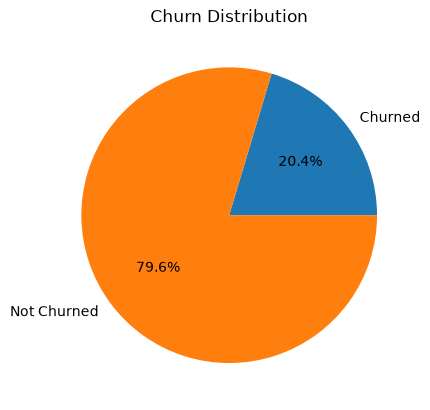

In [32]:
# Churn analysis
churn = (df['churn'] == 1).sum()
non_churn = (df['churn'] == 0).sum()
total_customers = len(df)
print("Total number of churned customers:", churn)


# Visualize churn distribution
plt.pie([churn, non_churn], labels=["Churned", "Not Churned"], autopct = '%1.1f%%')
plt.title('Churn Distribution')
plt.show()

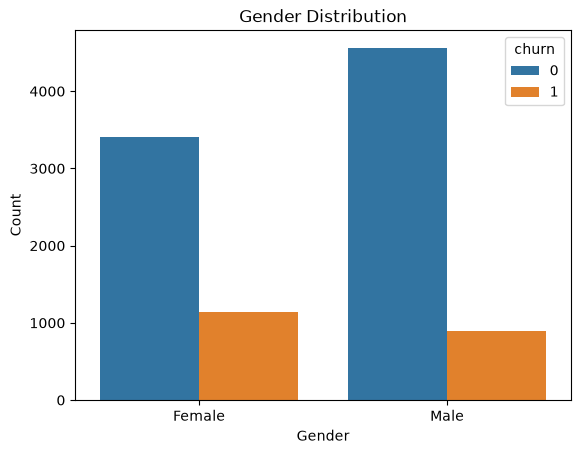

In [33]:
# Segmentation analysis: gender and churn
df['gender'] = np.where(df['gender_Female'] == 1, 'Female', 'Male')
sns.countplot(x='gender', hue='churn', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


To quantify the correlation between gender and customer churn, a count plot has been used. Although there are more male customers overall, female customers experience a higher absolute count and proportion of churn compared to males.

<Axes: xlabel='age', ylabel='Count'>

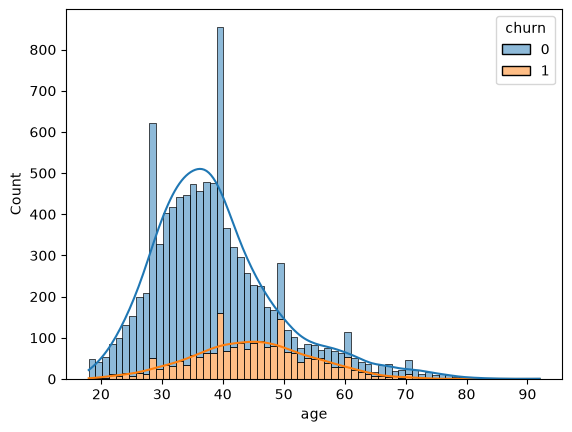

In [34]:
# Segmentation analysis: age and churn
sns.histplot(data = df, x = "age", hue= "churn", multiple= "stack", kde = True)

Younger customers (around ages 30–40) make up the majority of non-churned accounts. Older customers (peaking between ages 40 and 60) show a much higher rate of churn relative to their overall group size.

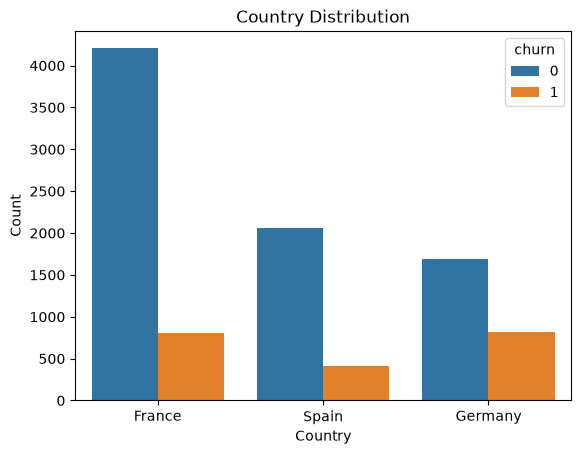

In [35]:
# Segmentation analysis: country and churn
df['country'] = np.where(
    df['country_France'] == 1, 'France',
    np.where(
        df['country_Germany'] == 1, 'Germany',
        np.where(
            df['country_Spain'] == 1, 'Spain',
            'Other'
        )
    )
)
sns.countplot(x = 'country', hue = 'churn', data = df)
plt.title('Country Distribution')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

France has the highest total of customer volume. The count plot based on country reveals Germany having a higher churn proportion relative to its base size compared to France and Spain. 

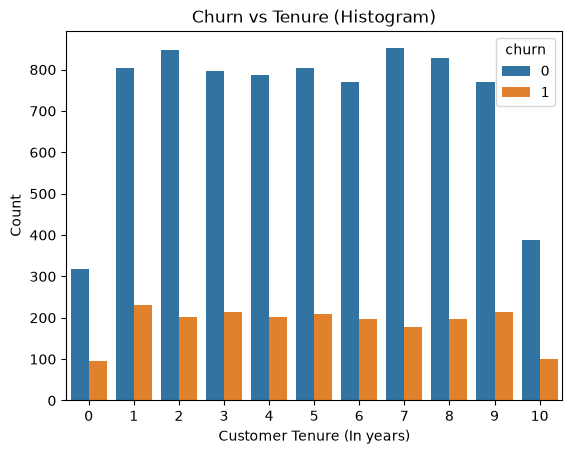

In [36]:
# Segmentation analysis: tenure
sns.countplot(x = 'tenure', hue = 'churn', data = df)
plt.xlabel('Customer Tenure (In years)')
plt.ylabel('Count') 
plt.title('Churn vs Tenure (Histogram)')
plt.show()


Text(0.5, 1.0, 'Estimated Salary Distribution')

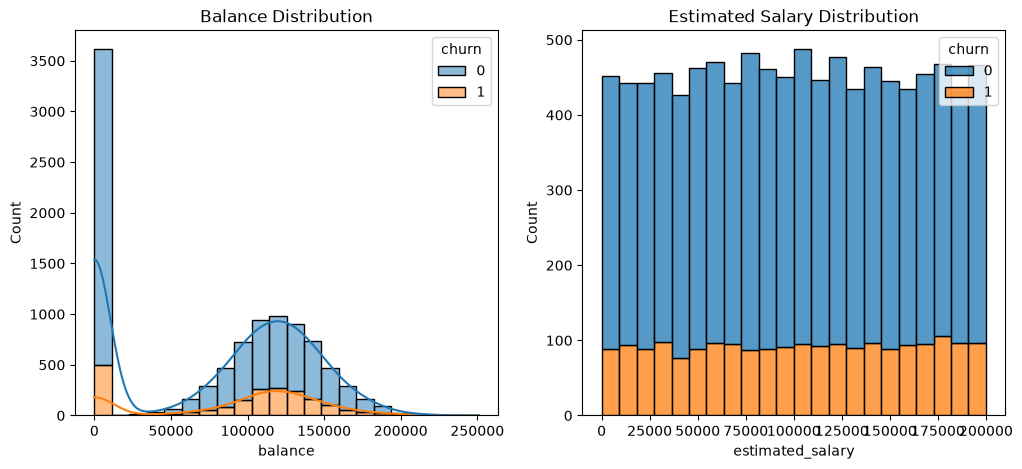

In [37]:
# Segmentation analysis: Balance & Estimated salary
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data = df, x = "balance", hue= "churn", multiple= "stack", kde = True, ax=axes[0])
axes[0].set_title('Balance Distribution')

sns.histplot(data = df, x = "estimated_salary", hue= "churn", multiple= "stack", ax=axes[1])
axes[1].set_title('Estimated Salary Distribution')


For non-zero balances, the distribution follows a normal curve around $100,000–$125,000, with higher balances correlating to a noticeable proportion of churn.
For the estimated salary distribution, the model is virtually uniform across all income brackets, showing minimal direct visual impact on whether a customer churns. 


<Axes: xlabel='churn', ylabel='credit_score'>

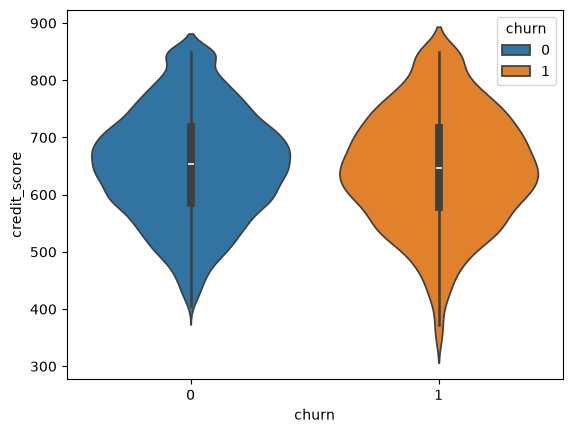

In [38]:
# Segmentation analysis: Credit score
sns.violinplot(data = df, x = "churn", y = "credit_score", hue= "churn")

The violin plot reveals both churned and non-churned distributions share nearly identical median values (around 650) and quartiles. However, churned customers show a slight tail extension at extremely low credit scores (< 400).

CORRELATION MATRIX

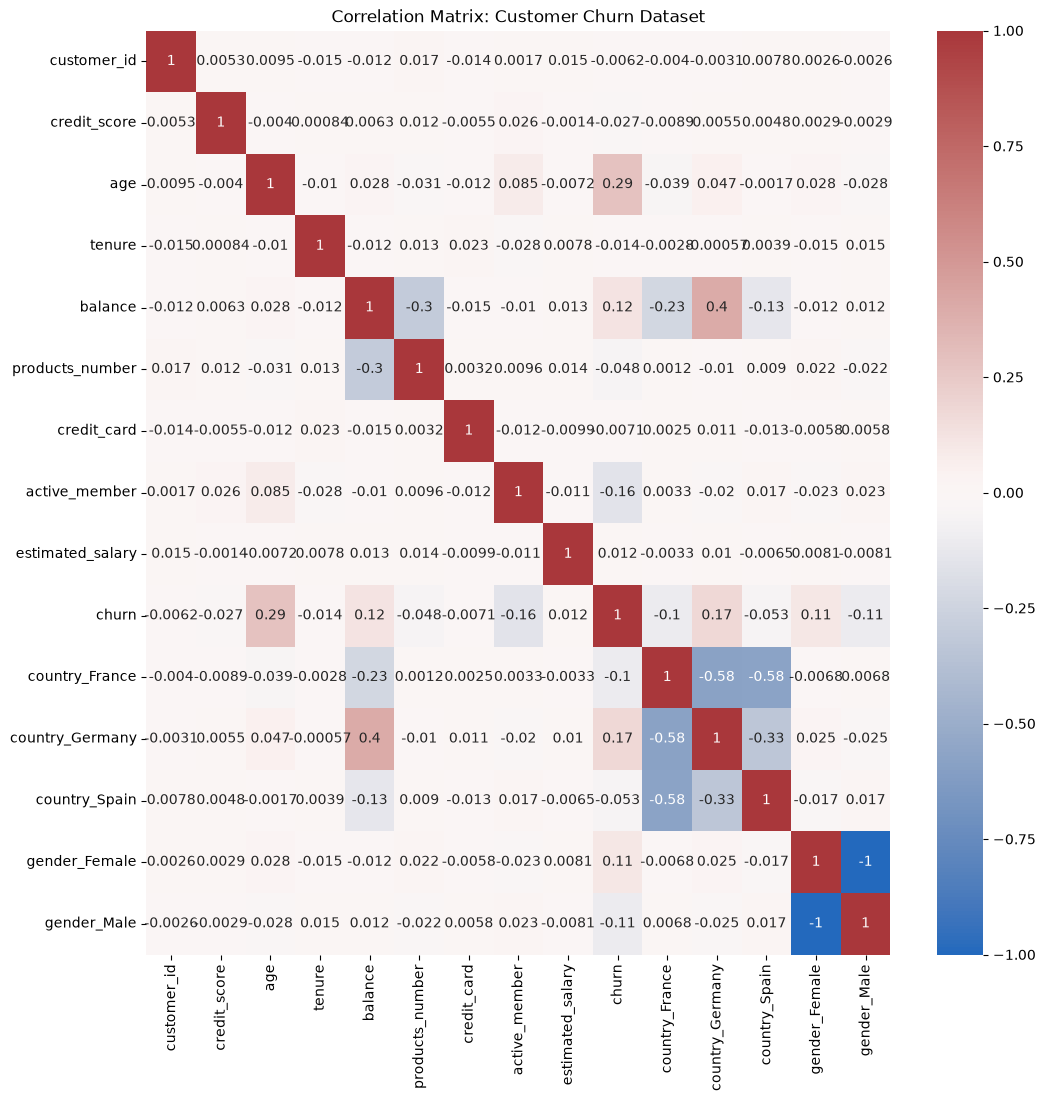

In [43]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(),annot = True,cmap='vlag')
plt.title('Correlation Matrix: Customer Churn Dataset')
plt.show()

The strongest positive correlation with churn is the customer’s age (0.29), followed by the customer being from Germany (0.17) and account balance (0.12). Negative correlations with churn include “active member” (-0.16), reflective of whether the customer is an active bank member and the customer’s gender being “male” (-0.11).

2. PREDICITVE MODELING
The data preprocessing, analysis and modeling is followed by model-building. In this phase, the tree-based model, XGBoost, is compared with the linear model, Logistic Regression, to assess their ability to accurately predict customer churn probability.
A pipeline was built for the respective models to ensure optimal usable of parameters. The models were then scored based on F1-performance – with the harmonic mean of the precision and recall being the pillar of performance.   

In [44]:
# Train / test split
X = df.drop(columns=['churn']) # Everything except the target variable
y = df['churn'] # Target variable 

X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 42, train_size = 0.8, shuffle = True)

In [45]:
# XGBoost Classifier
xgb_pipeline = Pipeline([
    ("model", xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid
param_grid_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:")
print(xgb_grid.best_params_)

print("Best CV F1:")
print(xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV F1:
0.5934017452959326


XGBoost Model Performance:
Accuracy: 0.8705
Precision: 0.7596899224806202
Recall: 0.49872773536895676
F1 Score: 0.6021505376344086

ConfusionMatrixDisplay for XGBoost:


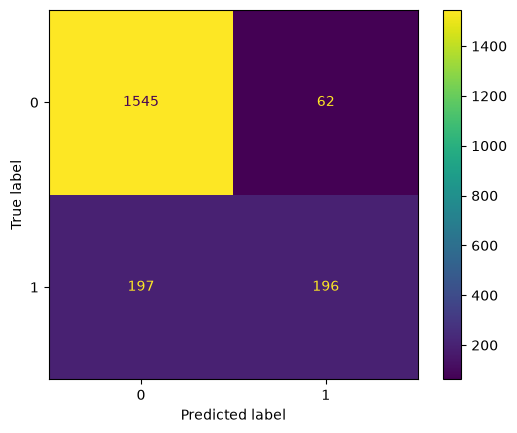


RocCurveDisplay for XGBoost:


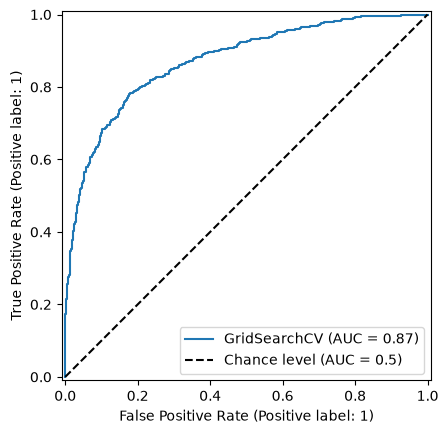

In [46]:
# Model performance for XGBoost
print("XGBoost Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb)) 
print()

print("ConfusionMatrixDisplay for XGBoost:")
confusion = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb))
confusion.plot()
plt.show()
print()

print("RocCurveDisplay for XGBoost:")
RocCurveDisplay.from_estimator(xgb_grid, X_test, y_test, plot_chance_level=True)

The model achieved an accuracy of 87.05% and a precision of 75.97%, indicating strong overall classification performance and reasonably reliable churn predictions. However, the recall of 49.87% shows that the model identifies only about half of actual churned customers. Consequently, the F1 score of 60.22% reflects a reasonable balance between precision and recall but highlights the model’s limited ability to detect churners.

The confusion matrix allows for quantification of the predictions in the test set. The model correctly predicted 1,545 non-churners and 196 churned customers. Conversely, it incorrectly predicted 197 churners as non-churners and 62 non-churners as churners.

The ROC curve demonstrates an Area Under the Curve (AUC) of 0.87, showing strong diagnostic ability to separate churners from non-churners above chance.

In [ ]:
# Logistic regression model
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])
logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

param_grid = [
    {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l1"],
        "model__solver": ["liblinear"],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["elasticnet"],
        "model__solver": ["saga"],
        "model__l1_ratio": [0.25, 0.5, 0.75],
        "model__class_weight": [None, "balanced"]
    }
]


logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

logreg_grid.fit(X_train, y_train)

print(logreg_grid.best_params_)
print(logreg_grid.best_score_)

best_logreg = logreg_grid.best_estimator_ 

y_pred_logreg = best_logreg.predict(X_test) 

Logistic Regression Model Performance:
Accuracy: 0.728
Precision: 0.39528432732316227
Recall: 0.7251908396946565
F1 Score: 0.5116696588868941

ConfusionMatrixDisplay for Logistic Regression:


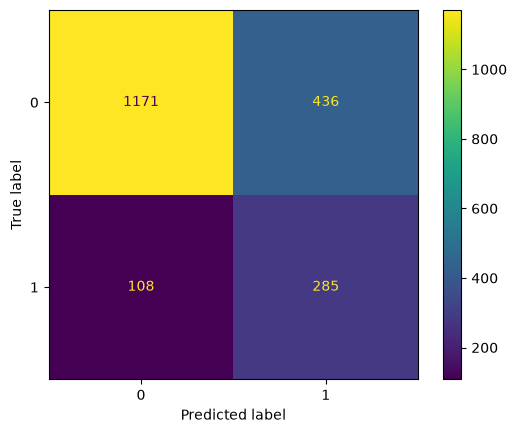


RocCurveDisplay for Logistic Regression:


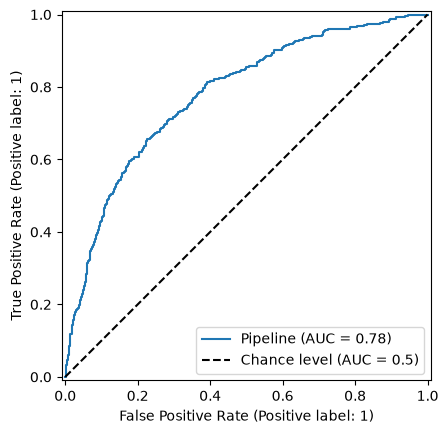

In [48]:
# Model performance for logistic regression
print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1 Score:", f1_score(y_test, y_pred_logreg)) 
print()

print("ConfusionMatrixDisplay for Logistic Regression:")
confusion = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_logreg))
confusion.plot()
plt.show()
print()

print("RocCurveDisplay for Logistic Regression:")
RocCurveDisplay.from_estimator(logreg_pipeline, X_test, y_test, plot_chance_level=True)

3. MODEL EXPLAINBILITY
The model explainability, to understand the key factors in the model's assessment, is extracted based on the best performing model: XGBoost.

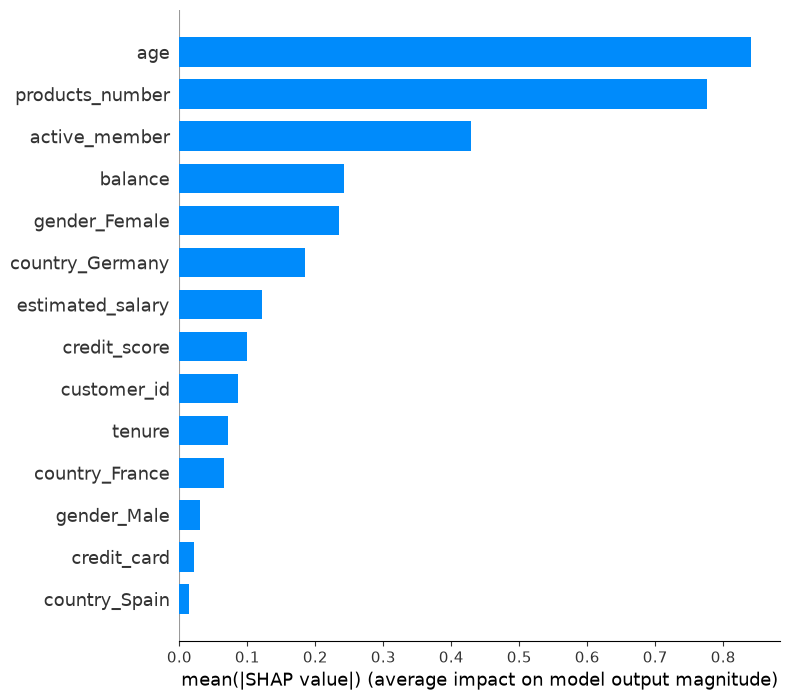

In [49]:
explainer = shap.Explainer(best_xgb.named_steps["model"])
shap_values = explainer(X_test)

shap_values = explainer.shap_values(X_test)
feature_names = X.columns

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=feature_names
)


In conclusion, age has the greatest average impact on the model’s predictions, with a mean absolute SHAP value of > 0.8. The products_name variable—representing the total number of banking products or services used by a customer, such as checking accounts, savings accounts, investments, and loans—is the second most influential predictor, with a mean absolute SHAP value of ≈ 0.79. Active membership status is the third most influential factor, with a mean absolute SHAP value of ≈ 0.43.